Generate data

In [1]:
import numpy as np
import SimultaneousPLN as SimPLN
import time
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

def variable_selection(Omega_real, Omega_hat):
    nodes = Omega_real.shape[0]
    adj_real = (Omega_real != 0)
    adj_hat = (Omega_hat != 0)
    nonzero_real = adj_real[~np.eye(adj_real.shape[0],dtype=bool)].flatten()
    nonzero_hat = adj_hat[~np.eye(adj_hat.shape[0],dtype=bool)].flatten()
    TP = np.sum(nonzero_real * nonzero_hat)
    FP = np.sum(nonzero_hat) - TP
    FN = np.sum(nonzero_real) - TP
    TN = np.sum(~nonzero_real & ~nonzero_hat)
    if TP + FP == 0:
        precision = 0
    else:
        precision = TP / (TP + FP)
    if TP + FN == 0:
        recall = 0
    else:
        recall = TP / (TP + FN)
    MCC = (TP * TN - FP * FN) / np.sqrt((TP + FP) * (TP + FN) * (TN + FP) * (TN + FN)) if (TP + FP) * (TP + FN) * (TN + FP) * (TN + FN) != 0 else 0
    return precision, recall, MCC

def offdiag_norm(Omega_real, Omega_hat, norm='fro'):
    nodes = Omega_real.shape[0]
    Offdiag_real = Omega_real.copy()
    np.fill_diagonal(Offdiag_real, 0)
    Offdiag_hat = Omega_hat.copy()
    np.fill_diagonal(Offdiag_hat, 0)
    return np.linalg.norm(Offdiag_real - Offdiag_hat, ord=norm)/np.sqrt(nodes*(nodes-1))

In [2]:
n, p, K, s = 200, 80, 30, 0.8
As = SimPLN.generate_graph("ErdosRenyi", "ErdosRenyi", nodes=p, groups=K, common_p=0.1/s, p=s)
values = [SimPLN.generate_value_uniform(nodes=p) for _ in range(K)]
Omegas = [SimPLN.sparse_Omega(As[i],values[i]) for i in range(K)]
y = [SimPLN.generate_PLN(Omegas[i], nsample=n) for i in range(K)]

Run SPLN

In [ ]:
model = SimPLN.SPLN(y)
v0s = list(np.array([0.1,0.5,1,2,5])/np.sqrt(n*np.log(p)))
start_time = time.time()
model.ModelSelect(v0_list=v0s, parallel=True, pen_diag=False, criterion='AIC')
Omega_est = model.Omega
end_time = time.time()
print("Time taken for model selection: {:.2f} seconds".format(end_time - start_time))
precision, recall, MCC, MNOFE = [None]*K, [None]*K, [None]*K, [None]*K
for i in range(K):
    precision[i], recall[i], MCC[i] = variable_selection(Omegas[i], Omega_est[i])
    MNOFE[i] = offdiag_norm(Omegas[i], Omega_est[i])

Param set [1/5]. Current setting: pi=0.5, rho=0.5, v1=3.38e-02, v0=3.38e-03, tau=10
Param set [2/5]. Current setting: pi=0.5, rho=0.5, v1=1.69e-01, v0=1.69e-02, tau=10                 
Param set [3/5]. Current setting: pi=0.5, rho=0.5, v1=3.38e-01, v0=3.38e-02, tau=10                 
Param set [4/5]. Current setting: pi=0.5, rho=0.5, v1=6.76e-01, v0=6.76e-02, tau=10                 
Param set [5/5]. Current setting: pi=0.5, rho=0.5, v1=1.69e+00, v0=1.69e-01, tau=10                 
Time taken for model selection: 100.90 seconds.44e-06                                               


In [4]:
df = pd.DataFrame({'precision':precision, 'recall':recall, 'MCC':MCC, 'MNOFE':MNOFE, 'method':'SPLN'})

Run SPLN-separate

In [5]:
v0s = list(np.array([0.1,0.5,1,2,5])/np.sqrt(n*np.log(p)))
start_time = time.time()
precision, recall, MCC, MNOFE, Omega_est = [None]*K, [None]*K, [None]*K, [None]*K, [None]*K
for i in range(K):
    model = SimPLN.SPLN([y[i]])
    model.ModelSelect(v0_list=v0s, parallel=True, pen_diag=False, criterion='AIC', param_verbose=False)
    Omega_est[i] = model.Omega[0]
end_time = time.time()
print("Time taken for model selection: {:.2f} seconds".format(end_time - start_time))
for i in range(K):
    precision[i], recall[i], MCC[i] = variable_selection(Omegas[i], Omega_est[i])
    MNOFE[i] = offdiag_norm(Omegas[i], Omega_est[i])

Time taken for model selection: 533.74 seconds.98e-07                                               


In [6]:
df = pd.concat([df, pd.DataFrame({'precision':precision, 'recall':recall, 'MCC':MCC, 'MNOFE':MNOFE, 'method':'SPLN-separate'})])

Run SPLN-population

In [7]:
v0s = list(np.array([0.1,0.5,1,2,5])/np.sqrt(n*np.log(p)))
for i in range(K):
    y_concat = np.vstack((y_concat, y[i])) if i>0 else y[i]
start_time = time.time()
precision, recall, MCC, MNOFE, Omega_est = [None]*K, [None]*K, [None]*K, [None]*K, [None]*K
model = SimPLN.SPLN([y_concat])
model.ModelSelect(v0_list=v0s, parallel=True, pen_diag=False, criterion='AIC')
Omega_est = model.Omega
end_time = time.time()
print("Time taken for model selection: {:.2f} seconds".format(end_time - start_time))
precision, recall, MCC, MNOFE = [None]*K, [None]*K, [None]*K, [None]*K
for i in range(K):
    precision[i], recall[i], MCC[i] = variable_selection(Omegas[i], Omega_est[0])
    MNOFE[i] = offdiag_norm(Omegas[i], Omega_est[0])

Param set [1/5]. Current setting: pi=0.5, rho=0.5, v1=3.38e-02, v0=3.38e-03, tau=10
Param set [2/5]. Current setting: pi=0.5, rho=0.5, v1=1.69e-01, v0=1.69e-02, tau=10                 
Param set [3/5]. Current setting: pi=0.5, rho=0.5, v1=3.38e-01, v0=3.38e-02, tau=10                 
Param set [4/5]. Current setting: pi=0.5, rho=0.5, v1=6.76e-01, v0=6.76e-02, tau=10                 
Param set [5/5]. Current setting: pi=0.5, rho=0.5, v1=1.69e+00, v0=1.69e-01, tau=10                 
Time taken for model selection: 21.72 seconds3.53e-08                                               


In [8]:
df = pd.concat([df, pd.DataFrame({'precision':precision, 'recall':recall, 'MCC':MCC, 'MNOFE':MNOFE, 'method':'SPLN-population'})])

Plot the metrics

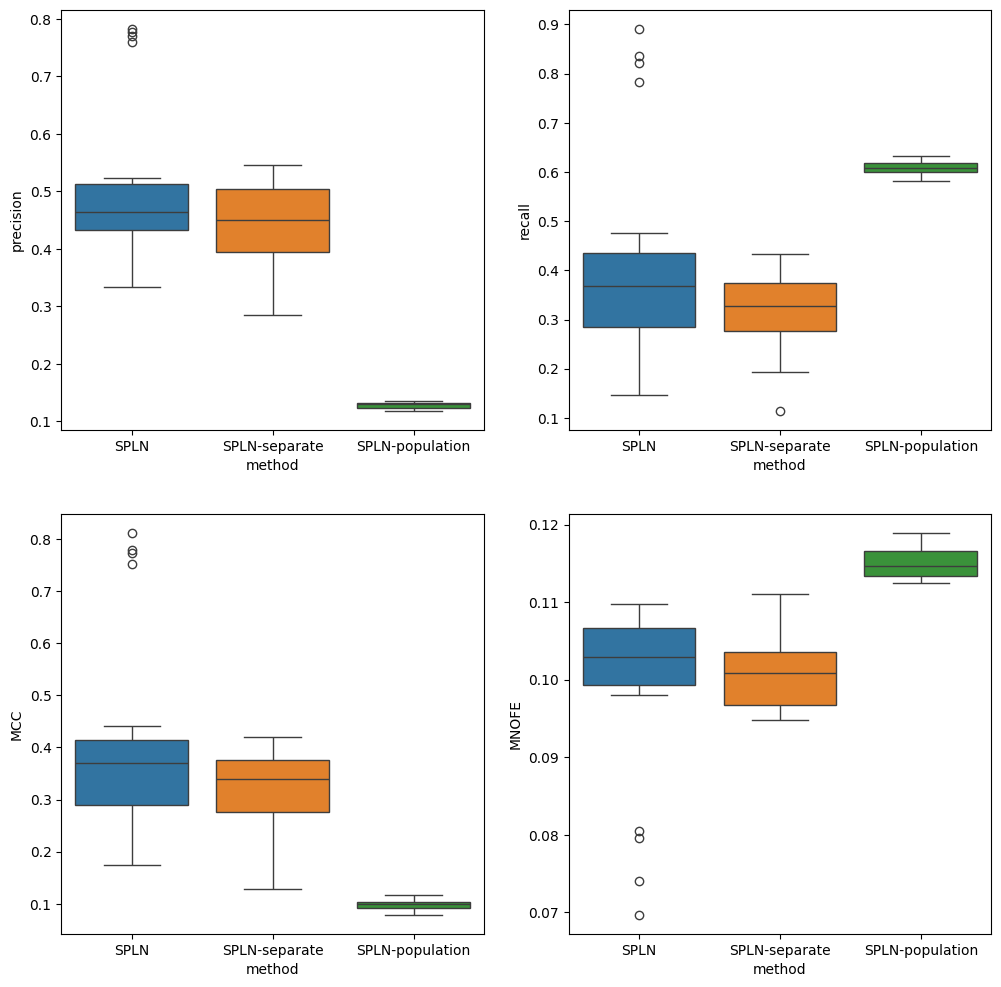

In [9]:
fig, axs = plt.subplots(2, 2, figsize=(12,12))
metrics = ['precision', 'recall', 'MCC', 'MNOFE']
for i in range(4):
    sns.boxplot(data=df,x='method',y=metrics[i],hue='method',ax=axs[i//2,i%2])
